# Edge AI Brain Tumor Detection
Standalone detection layer built on the existing INT8 ONNX U-Net segmentation model.

In [1]:
# Imports
import time
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
from IPython.display import Image, display

In [2]:
# Configuration
DEFAULT_MODEL = Path("models/unet_int8.onnx")
DEFAULT_OUTPUT = Path("results/detection_result.png")

# Minimum predicted tumor area as a fraction of the MRI slice (0.001 = 0.1% area ~= 58 pixels)
DEFAULT_AREA_THRESHOLD = 0.001

# Neural-network segmentation threshold
DEFAULT_PROBABILITY_THRESHOLD = 0.5

In [3]:
# Data loading
def load_h5_slice(h5_path: Path) -> tuple[np.ndarray, np.ndarray | None]:
    """Load one MRI slice and optional ground-truth mask from an H5 file."""
    with h5py.File(h5_path, "r") as f:
        if "x" not in f:
            raise KeyError("H5 file does not contain required dataset 'x'.")

        image = np.asarray(f["x"])

        ground_truth = None
        if "y" in f:
            ground_truth = np.asarray(f["y"])

    image = np.squeeze(image).astype(np.float32)

    if image.ndim != 2:
        raise ValueError(
            f"Expected a 2D MRI slice after squeezing, got shape {image.shape}."
        )

    if ground_truth is not None:
        ground_truth = np.squeeze(ground_truth)
        if ground_truth.shape != image.shape:
            raise ValueError(
                f"Image shape {image.shape} does not match "
                f"ground-truth shape {ground_truth.shape}."
            )
        ground_truth = (ground_truth > 0).astype(np.uint8)

    return image, ground_truth

In [4]:
# Preprocessing
def preprocess(image: np.ndarray) -> np.ndarray:
    """Match the exact preprocessing used by the verified inference pipeline."""
    return image.astype(np.float32)[None, None, :, :]

In [5]:
# ONNX session
def create_session(model_path: Path) -> ort.InferenceSession:
    """Create an ONNX Runtime CPU session."""
    model_path = Path(model_path)
    if not model_path.exists():
        candidate = Path("..") / model_path
        if candidate.exists():
            model_path = candidate
        else:
            raise FileNotFoundError(
                f"INT8 model not found: {model_path}\n"
                f"Run this notebook from the project root or pass a valid model path."
            )

    return ort.InferenceSession(
        str(model_path),
        providers=["CPUExecutionProvider"],
    )

In [6]:
# Inference
def run_inference(
    session: ort.InferenceSession,
    image: np.ndarray,
    probability_threshold: float = DEFAULT_PROBABILITY_THRESHOLD,
) -> tuple[np.ndarray, np.ndarray, float, float]:
    """Run INT8 U-Net inference and return mask, probabilities, latency, FPS."""
    input_name = session.get_inputs()[0].name
    input_tensor = preprocess(image)

    start = time.perf_counter()

    output = session.run(None, {input_name: input_tensor})[0]

    elapsed_ms = (time.perf_counter() - start) * 1000.0
    fps = 1000.0 / elapsed_ms if elapsed_ms > 0 else 0.0

    # ONNX post-processing matching verified inference pipeline
    probability = 1.0 / (1.0 + np.exp(-output))

    prediction = (
        probability > probability_threshold
    ).astype(np.uint8)[0, 0]

    return prediction, probability[0, 0], elapsed_ms, fps

In [7]:
# Detection
def detect_tumor(
    prediction: np.ndarray,
    min_area_fraction: float = DEFAULT_AREA_THRESHOLD,
) -> dict:
    """
    Convert a segmentation mask into a tumor presence decision.

    Detection is derived from the predicted segmentation area.
    """
    mask = np.asarray(prediction).astype(bool)

    if mask.ndim != 2:
        raise ValueError(
            f"Expected a 2D segmentation mask, got shape {mask.shape}."
        )

    if not 0.0 <= min_area_fraction <= 1.0:
        raise ValueError("Detection area threshold must be between 0 and 1.")

    tumor_pixels = int(prediction.sum())
    total_pixels = int(prediction.size)
    tumor_area_fraction = tumor_pixels / total_pixels

    threshold_pixels = max(
        1,
        int(np.ceil(total_pixels * min_area_fraction)),
    )

    detected = tumor_pixels >= threshold_pixels

    return {
        "detected": bool(detected),
        "label": "TUMOR DETECTED" if detected else "NO TUMOR DETECTED",
        "tumor_pixels": tumor_pixels,
        "total_pixels": total_pixels,
        "tumor_area_fraction": tumor_area_fraction,
        "tumor_area_percent": tumor_area_fraction * 100.0,
        "threshold_pixels": threshold_pixels,
        "threshold_fraction": min_area_fraction,
    }

In [8]:
# Evaluation
def compute_dice(prediction: np.ndarray, ground_truth: np.ndarray) -> float:
    """Compute Dice score when ground truth is available."""
    prediction = prediction.astype(bool)
    ground_truth = ground_truth.astype(bool)

    intersection = np.logical_and(prediction, ground_truth).sum()

    denominator = prediction.sum() + ground_truth.sum()

    if denominator == 0:
        return 1.0

    return float((2.0 * intersection) / denominator)

In [9]:
# Visualization
def save_visualization(
    image: np.ndarray,
    prediction: np.ndarray,
    probabilities: np.ndarray,
    detection: dict,
    output_path: Path,
    ground_truth: np.ndarray | None = None,
) -> None:
    """Save a 3/4-panel detection and segmentation visualization."""
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if ground_truth is not None:
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))
        axes = axes.ravel()

        axes[0].imshow(image, cmap="gray")
        axes[0].set_title("MRI Input")

        axes[1].imshow(image, cmap="gray")
        axes[1].imshow(
            ground_truth,
            cmap="Reds",
            alpha=0.65,
            interpolation="nearest",
        )
        axes[1].set_title("Ground Truth")

        axes[2].imshow(image, cmap="gray")
        axes[2].imshow(
            prediction,
            cmap="Blues",
            alpha=0.65,
            interpolation="nearest",
        )
        axes[2].set_title(
            f"Predicted Segmentation\n{detection['tumor_pixels']:,} tumor pixels"
        )

        axes[3].imshow(probabilities, cmap="inferno", vmin=0, vmax=1)
        axes[3].set_title("Tumor Probability Map")

    else:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(image, cmap="gray")
        axes[0].set_title("MRI Input")

        axes[1].imshow(image, cmap="gray")
        axes[1].imshow(
            prediction,
            cmap="Blues",
            alpha=0.65,
            interpolation="nearest",
        )
        axes[1].set_title(
            f"Segmentation\n{detection['tumor_pixels']:,} tumor pixels"
        )

        axes[2].imshow(probabilities, cmap="inferno", vmin=0, vmax=1)
        axes[2].set_title("Tumor Probability Map")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{detection['label']} | "
        f"Tumor area: {detection['tumor_area_percent']:.3f}%",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)

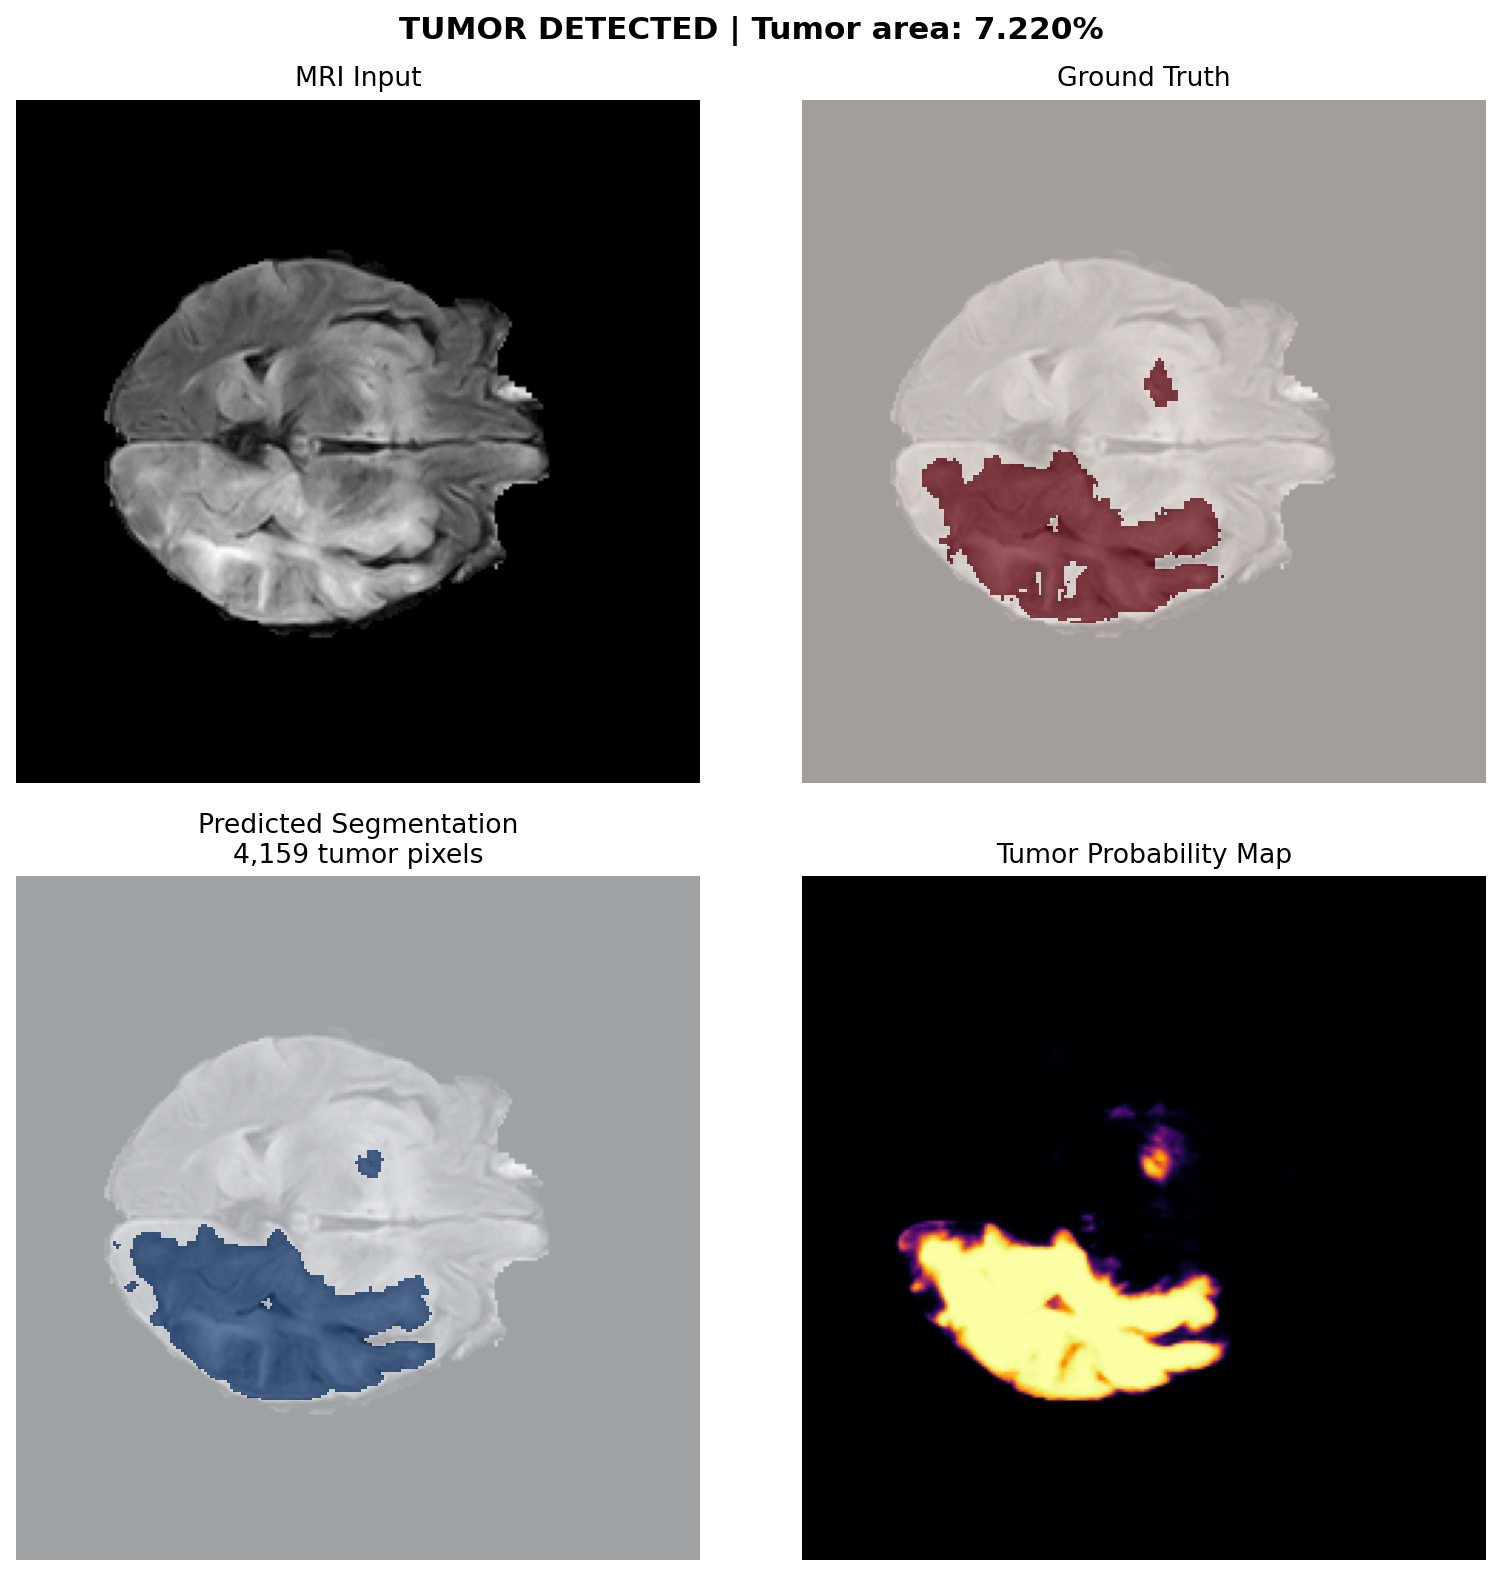

In [10]:
# Input file configuration + complete inference execution
import sys
from pathlib import Path
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

# Ensure functions and dependencies are available even if run directly
if "create_session" not in globals() or "load_h5_slice" not in globals():
    from detection.tumor_detection import (
        load_h5_slice, preprocess, create_session, run_inference,
        detect_tumor, compute_dice, save_visualization,
        DEFAULT_MODEL, DEFAULT_OUTPUT, DEFAULT_AREA_THRESHOLD, DEFAULT_PROBABILITY_THRESHOLD
    )
if "display" not in globals():
    from IPython.display import Image, display

# Specify the H5 MRI slice to evaluate (change this path as needed)
H5_FILE = Path(r"C:\Users\SUBHAM\Desktop\IEEE_Dataset\extracted\BRATS_241\BRATS_241_68.h5")
if not H5_FILE.exists():
    H5_FILE = Path("path/to/BRATS_241_68.h5")

MODEL_PATH = DEFAULT_MODEL
AREA_THRESHOLD = DEFAULT_AREA_THRESHOLD
OUTPUT_IMAGE = DEFAULT_OUTPUT

# Load MRI slice and optional ground truth
image, ground_truth = load_h5_slice(H5_FILE)

# Create INT8 ONNX session
session = create_session(MODEL_PATH)

# Run INT8 inference
prediction, probabilities, latency_ms, fps = run_inference(
    session,
    image,
    probability_threshold=DEFAULT_PROBABILITY_THRESHOLD,
)

# Derive detection decision from segmentation mask
detection = detect_tumor(prediction, min_area_fraction=AREA_THRESHOLD)

# Compute Dice score if ground truth is available
dice = compute_dice(prediction, ground_truth) if ground_truth is not None else None

# Save visualization to disk
save_visualization(
    image=image,
    prediction=prediction,
    probabilities=probabilities,
    detection=detection,
    output_path=OUTPUT_IMAGE,
    ground_truth=ground_truth,
)

# Display visualization inline in notebook
display(Image(filename=str(OUTPUT_IMAGE)))

In [11]:
# Final results / output printing
import sys
from pathlib import Path
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

# Safeguard: ensure all variables exist even if this cell is executed independently
if "detection" not in globals() or detection is None:
    from detection.tumor_detection import (
        load_h5_slice, preprocess, create_session, run_inference,
        detect_tumor, compute_dice, save_visualization,
        DEFAULT_MODEL, DEFAULT_OUTPUT, DEFAULT_AREA_THRESHOLD, DEFAULT_PROBABILITY_THRESHOLD
    )
    H5_FILE = Path(r"C:\Users\SUBHAM\Desktop\IEEE_Dataset\extracted\BRATS_241\BRATS_241_68.h5")
    if not H5_FILE.exists():
        H5_FILE = Path("path/to/BRATS_241_68.h5")
    MODEL_PATH = DEFAULT_MODEL
    AREA_THRESHOLD = DEFAULT_AREA_THRESHOLD
    OUTPUT_IMAGE = DEFAULT_OUTPUT

    image, ground_truth = load_h5_slice(H5_FILE)
    session = create_session(MODEL_PATH)
    prediction, probabilities, latency_ms, fps = run_inference(
        session,
        image,
        probability_threshold=DEFAULT_PROBABILITY_THRESHOLD,
    )
    detection = detect_tumor(prediction, min_area_fraction=AREA_THRESHOLD)
    dice = compute_dice(prediction, ground_truth) if ground_truth is not None else None

print("=" * 65)
print("EDGE AI BRAIN TUMOR DETECTION")
print("=" * 65)
print(f"\nMRI input           : {H5_FILE}")
print(f"INT8 model          : {MODEL_PATH}")
print(f"Image shape         : {image.shape}")

print("\n" + "-" * 65)
print("TUMOR DETECTION RESULT")
print("-" * 65)
print(f"Detection result    : {detection['label']}")
print(f"Tumor pixels        : {detection['tumor_pixels']:,}")
print(f"Total image pixels  : {detection['total_pixels']:,}")
print(f"Tumor area          : {detection['tumor_area_percent']:.3f}%")
print(
    f"Detection threshold : {detection['threshold_pixels']:,} pixels "
    f"({detection['threshold_fraction'] * 100:.3f}%)"
)

print("\n" + "-" * 65)
print("EDGE INFERENCE")
print("-" * 65)
print(f"Runtime             : INT8 ONNX Runtime / CPU")
print(f"Latency             : {latency_ms:.2f} ms")
print(f"Throughput          : {fps:.2f} FPS")
print(f"Probability cutoff  : {DEFAULT_PROBABILITY_THRESHOLD:.2f}")

if dice is not None:
    print(f"Segmentation Dice   : {dice * 100:.2f}%")

print(f"\nVisualization saved : {OUTPUT_IMAGE}")
print("\n" + "=" * 65)
print("NOTE: Detection is derived from the segmentation mask.")
print("This is a hackathon/research prototype, not a medical device.")
print("=" * 65)

EDGE AI BRAIN TUMOR DETECTION

MRI input           : C:\Users\SUBHAM\Desktop\IEEE_Dataset\extracted\BRATS_241\BRATS_241_68.h5
INT8 model          : models\unet_int8.onnx
Image shape         : (240, 240)

-----------------------------------------------------------------
TUMOR DETECTION RESULT
-----------------------------------------------------------------
Detection result    : TUMOR DETECTED
Tumor pixels        : 4,159
Total image pixels  : 57,600
Tumor area          : 7.220%
Detection threshold : 58 pixels (0.100%)

-----------------------------------------------------------------
EDGE INFERENCE
-----------------------------------------------------------------
Runtime             : INT8 ONNX Runtime / CPU
Latency             : 122.28 ms
Throughput          : 8.18 FPS
Probability cutoff  : 0.50
Segmentation Dice   : 92.87%

Visualization saved : results\detection_result.png

NOTE: Detection is derived from the segmentation mask.
This is a hackathon/research prototype, not a medical de